In [5]:
# -------------------- IMPORT --------------------
import pandas as pd


In [7]:
# -------------------- LOAD DATA --------------------
ds = pd.read_csv("insurance.csv")
print(ds.head())
print(ds.info())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [8]:
# -------------------- CHECK NULLS --------------------
print("\nMissing Values:\n", ds.isnull().sum())



Missing Values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [9]:
# -------------------- ENCODING --------------------

# Convert binary categorical columns
ds['sex'] = ds['sex'].map({'male': 1, 'female': 0})
ds['smoker'] = ds['smoker'].map({'yes': 1, 'no': 0})

In [10]:
# One-hot encoding for region
ds = pd.get_dummies(ds, columns=['region'], drop_first=True)

print("\nAfter Encoding:\n", ds.head())


After Encoding:
    age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400             False   
1   18    1  33.770         1       0   1725.55230             False   
2   28    1  33.000         3       0   4449.46200             False   
3   33    1  22.705         0       0  21984.47061              True   
4   32    1  28.880         0       0   3866.85520              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [11]:
# -------------------- FEATURES & TARGET --------------------
X = ds.drop("charges", axis=1)
y = ds["charges"]


In [12]:
# -------------------- TRAIN TEST SPLIT --------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
# -------------------- MODEL --------------------
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
# -------------------- COEFFICIENTS --------------------
print("\nModel Coefficients:")
for col, coef in zip(X.columns, model.coef_):
    print(f"{col}: {coef}")

print("Intercept:", model.intercept_)


Model Coefficients:
age: 256.9757058311941
sex: -18.59169164105173
bmi: 337.0925519487796
children: 425.27878352429815
smoker: 23651.12885576125
region_northwest: -370.6773262277959
region_southeast: -657.8642965646382
region_southwest: -809.7993541824796
Intercept: -11931.219050326681


In [15]:
# -------------------- EVALUATION --------------------
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt


In [16]:
# Training
y_pred_train = model.predict(X_train)

print("\n--- Training Performance ---")
print("MSE:", mean_squared_error(y_train, y_pred_train))
print("RMSE:", sqrt(mean_squared_error(y_train, y_pred_train)))
print("R2 Score:", r2_score(y_train, y_pred_train))


--- Training Performance ---
MSE: 37277681.70201867
RMSE: 6105.545160099848
R2 Score: 0.7417255854683333


In [17]:
# Testing
y_pred_test = model.predict(X_test)

print("\n--- Testing Performance ---")
print("MSE:", mean_squared_error(y_test, y_pred_test))
print("R2 Score:", r2_score(y_test, y_pred_test))



--- Testing Performance ---
MSE: 33596915.851361446
R2 Score: 0.7835929767120724


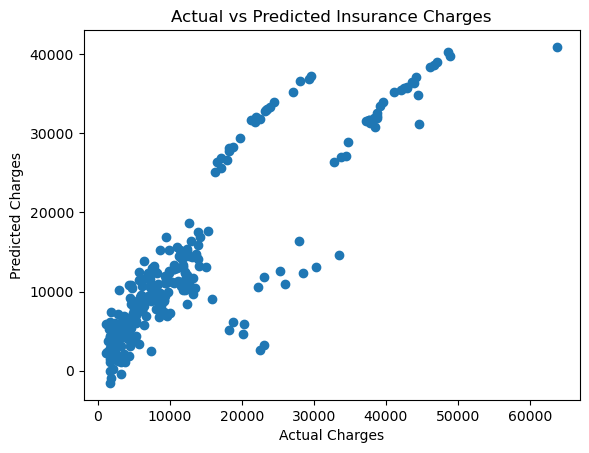

In [18]:
# -------------------- VISUALIZATION --------------------
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.show()


In [19]:
# -------------------- USER INPUT --------------------
print("\n--- Enter Data for Prediction ---")

age = int(input("Age: "))
sex = int(input("Sex (1=Male, 0=Female): "))
bmi = float(input("BMI: "))
children = int(input("Children: "))
smoker = int(input("Smoker (1=Yes, 0=No): "))


--- Enter Data for Prediction ---


Age:  20
Sex (1=Male, 0=Female):  1
BMI:  33
Children:  0
Smoker (1=Yes, 0=No):  1


In [20]:
# region input (manual handling)
region = input("Region (southwest, southeast, northwest, northeast): ").lower()


Region (southwest, southeast, northwest, northeast):  southeast


In [21]:
# create base input
input_data = {
    'age': age,
    'sex': sex,
    'bmi': bmi,
    'children': children,
    'smoker': smoker,
    'region_northwest': 0,
    'region_southeast': 0,
    'region_southwest': 0
}

In [22]:

# set correct region
if region == "northwest":
    input_data['region_northwest'] = 1
elif region == "southeast":
    input_data['region_southeast'] = 1
elif region == "southwest":
    input_data['region_southwest'] = 1

In [23]:
# northeast is default (all 0)

input_df = pd.DataFrame([input_data])

prediction = model.predict(input_df)

print("\nPredicted Insurance Charges:", round(prediction[0], 2))


Predicted Insurance Charges: 27307.02
